# Phase 2: Exploratory Data Analysis

**Predicting 30-Day Hospital Readmission for Diabetic Patients**

Loads Phase 1 artifact (`phase1_df_raw.parquet`) and performs full EDA.
Phase 2 does not produce modeling artifacts — findings inform Phase 3 decisions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

COLORS = {
    'primary': '#1B2A4A',
    'steel': '#4A7FB5',
    'teal': '#2AA198',
    'orange': '#E67E22',
    'red': '#E74C3C',
    'green': '#2ECC71',
    'gold': '#D4A017'
}

print('Environment ready.')


### 📂 Load Phase 1 Artifact

In [ ]:
ARTIFACTS_DIR = '../artifacts'

df = pd.read_parquet(f'{ARTIFACTS_DIR}/phase1_df_raw.parquet')

# Figures folder (same relative path as master)
import os
os.makedirs('../figures', exist_ok=True)

print(f'✅ Phase 1 artifact loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'   Columns: {list(df.columns[:6])} ... ({df.shape[1]} total)')


### 2.1 Recreate Target and Load IDs Mapping

Phase 1 dropped `readmit_30` at the end of profiling to keep `df` clean. Recreate it here for Phase 2 analysis, and load the ID-to-label mappings for the coded columns.

In [16]:
# Recreate the binary target for Phase 2 analysis
df['readmit_30'] = (df['readmitted'] == '<30').astype(int)
print(f"readmit_30 recreated: {df['readmit_30'].sum():,} positives ({df['readmit_30'].mean()*100:.1f}%)")

# Load ID mappings -- try CSV first, fallback to inline dicts
import os

id_mapping_path = './Data/IDs_mapping.csv'
if os.path.exists(id_mapping_path):
    ids_df = pd.read_csv(id_mapping_path)
    print(f"Loaded IDs_mapping.csv: {len(ids_df)} rows")

# Define mappings inline (used regardless -- the CSV format is awkward to parse)
admission_type_map = {
    1: 'Emergency', 2: 'Urgent', 3: 'Elective', 4: 'Newborn',
    5: 'Not Available', 6: 'NULL', 7: 'Trauma Center', 8: 'Not Mapped'
}

discharge_disposition_map = {
    1: 'Discharged to Home', 2: 'Short-term Hospital', 3: 'SNF', 4: 'ICF',
    5: 'Other', 6: 'Home Health', 7: 'AMA', 8: 'Not Available',
    9: 'Admitted as Inpatient', 10: 'Neoplasm', 11: 'Expired',
    13: 'Hospice/Home', 14: 'Hospice/Medical', 15: 'Swing Bed',
    18: 'NULL', 19: 'Expired at Home', 20: 'Expired in Medical Facility',
    21: 'Expired Place Unknown', 22: 'Rehab', 23: 'Long-term Care',
    25: 'Psych', 27: 'Fed Health', 28: 'Psych w/ planned readmit'
}

admission_source_map = {
    1: 'Physician Referral', 2: 'Clinic Referral', 3: 'HMO Referral',
    4: 'Transfer from Hospital', 5: 'Transfer from SNF',
    6: 'Transfer from Other', 7: 'Emergency Room',
    8: 'Court/Law Enforcement', 9: 'Not Available',
    10: 'Transfer from Critical Access', 11: 'Normal Delivery',
    17: 'NULL', 20: 'Not Mapped', 22: 'Transfer Intra-Hospital',
    25: 'Transfer from Ambulatory'
}

print(f"\nID mappings defined:")
print(f"  admission_type_id:        {len(admission_type_map)} categories")
print(f"  discharge_disposition_id:  {len(discharge_disposition_map)} categories")
print(f"  admission_source_id:       {len(admission_source_map)} categories")

readmit_30 recreated: 11,357 positives (11.2%)
Loaded IDs_mapping.csv: 67 rows

ID mappings defined:
  admission_type_id:        8 categories
  discharge_disposition_id:  23 categories
  admission_source_id:       15 categories


### 2.2 Correlation Analysis

Examine pairwise correlations among all numeric features and the binary target. With ~100K observations, even tiny correlations will be statistically significant -- focus on magnitude, not p-values.

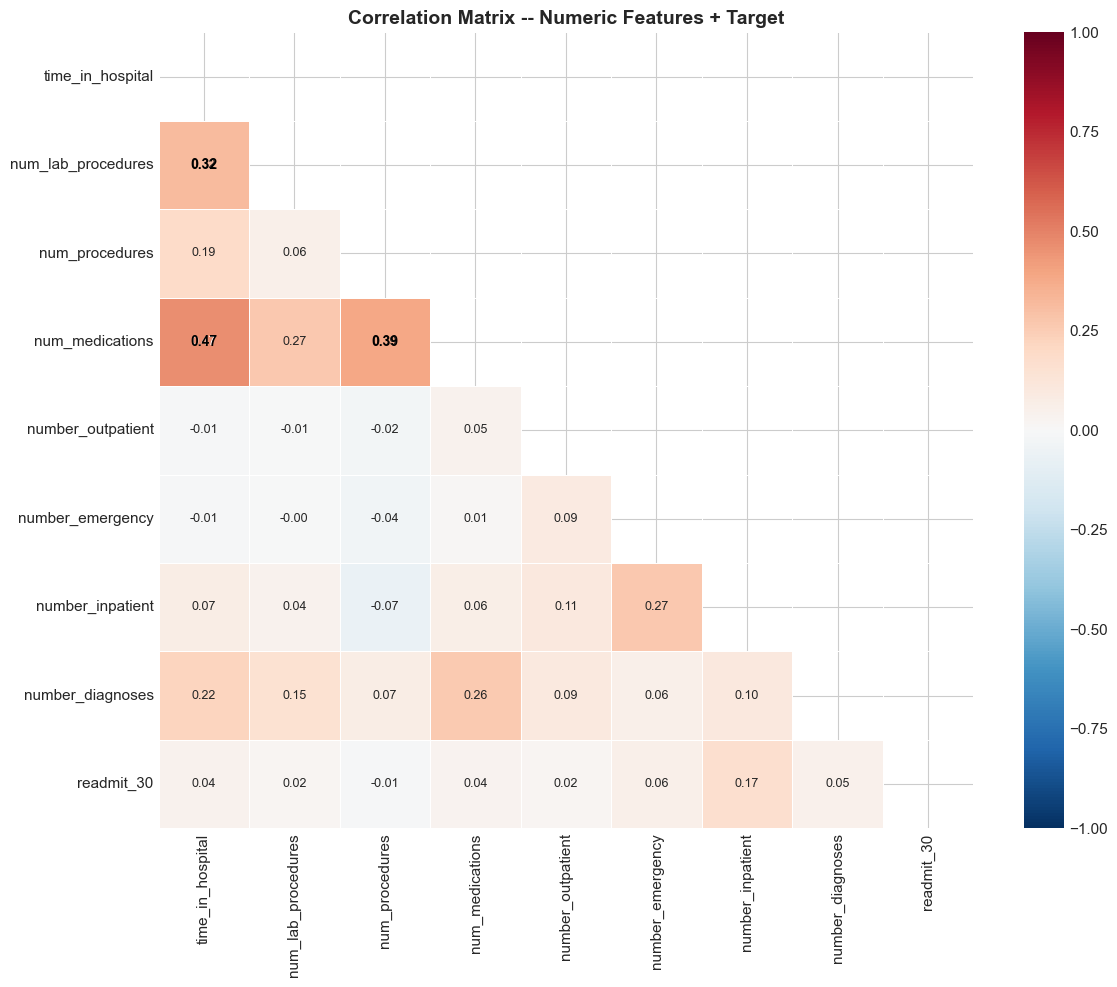


Top features by |correlation| with readmit_30:
---------------------------------------------
  number_inpatient          r = +0.1651
  number_emergency          r = +0.0607
  number_diagnoses          r = +0.0495
  time_in_hospital          r = +0.0442
  num_medications           r = +0.0384
  num_lab_procedures        r = +0.0204
  number_outpatient         r = +0.0189
  num_procedures            r = -0.0122


In [17]:
# Correlation matrix for numeric features + target
numeric_cols_for_corr = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'readmit_30'
]

corr_matrix = df[numeric_cols_for_corr].corr()

# Lower-triangle mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9},
    ax=ax
)

# Bold-highlight cells with |r| > 0.3
for i in range(len(corr_matrix)):
    for j in range(i):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.3:
            ax.text(j + 0.5, i + 0.5, f'{val:.2f}',
                    ha='center', va='center', fontweight='bold',
                    fontsize=10, color='black')

ax.set_title('Correlation Matrix -- Numeric Features + Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 10 features by absolute correlation with readmit_30
target_corr = corr_matrix['readmit_30'].drop('readmit_30').abs().sort_values(ascending=False)
print("\nTop features by |correlation| with readmit_30:")
print("-" * 45)
for feat, r in target_corr.items():
    direction = "+" if corr_matrix.loc[feat, 'readmit_30'] > 0 else "-"
    print(f"  {feat:<25} r = {direction}{r:.4f}")

**Correlation analysis findings:** All individual correlations with the target are weak (|r| < 0.10), which is expected for this dataset -- readmission is driven by complex interactions rather than single linear relationships. `number_inpatient` shows the strongest positive correlation, confirming the Phase 1 finding that prior hospitalizations are the best single predictor. Among feature pairs, `time_in_hospital` correlates moderately with `num_lab_procedures` and `num_medications`, reflecting that longer stays involve more treatment. These inter-feature correlations will not cause problems for tree-based models but may affect logistic regression coefficients.

### 2.3 Discharge Disposition Deep-Dive

Discharge disposition describes where the patient went after leaving the hospital. This is one of the strongest clinical predictors of readmission and also contains the "Expired" codes that must be removed during cleaning.

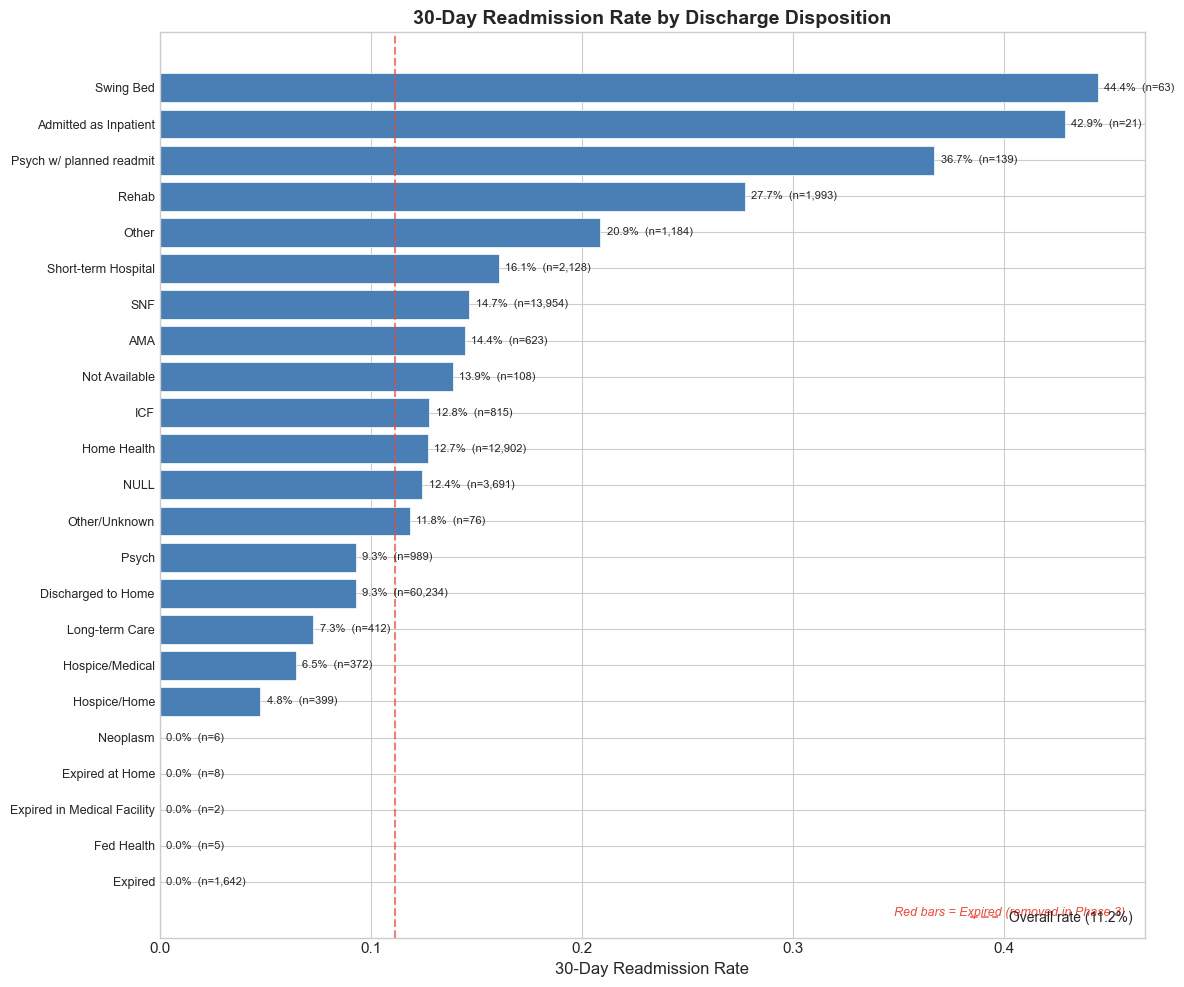


Expired patients (codes [11, 19, 20, 21]): 1,652 encounters -- will be removed in Phase 3


In [18]:
# Map discharge_disposition_id to readable labels
discharge_labels = df['discharge_disposition_id'].map(discharge_disposition_map).fillna('Other/Unknown')

# Compute readmission rate and count per disposition
discharge_stats = pd.DataFrame({
    'readmission_rate': df.groupby(discharge_labels)['readmit_30'].mean(),
    'count': df.groupby(discharge_labels)['readmit_30'].count()
}).sort_values('readmission_rate', ascending=True)

# Identify expired categories
expired_labels = ['Expired', 'Expired at Home', 'Expired in Medical Facility', 'Expired Place Unknown']
overall_rate = df['readmit_30'].mean()

fig, ax = plt.subplots(figsize=(12, 10))

bar_colors = [COLORS['red'] if label in expired_labels else COLORS['steel']
              for label in discharge_stats.index]

bars = ax.barh(range(len(discharge_stats)), discharge_stats['readmission_rate'],
               color=bar_colors, edgecolor='white', linewidth=0.5)

ax.set_yticks(range(len(discharge_stats)))
ax.set_yticklabels(discharge_stats.index, fontsize=9)
ax.axvline(x=overall_rate, color=COLORS['red'], linestyle='--', alpha=0.7,
           linewidth=1.5, label=f'Overall rate ({overall_rate:.1%})')

# Annotate each bar with n= and rate %
for i, (label, row) in enumerate(discharge_stats.iterrows()):
    rate_text = f"{row['readmission_rate']:.1%}  (n={row['count']:,.0f})"
    ax.text(row['readmission_rate'] + 0.003, i, rate_text, va='center', fontsize=8)

ax.set_xlabel('30-Day Readmission Rate', fontsize=12)
ax.set_title('30-Day Readmission Rate by Discharge Disposition', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)

# Add a note about expired categories
ax.text(0.98, 0.02, 'Red bars = Expired (removed in Phase 3)',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, color=COLORS['red'], fontstyle='italic')

plt.tight_layout()
plt.savefig('../figures/discharge_disposition_readmission.png', dpi=150, bbox_inches='tight')
plt.show()

# Print expired patient counts
expired_codes = [11, 19, 20, 21]
n_expired = df['discharge_disposition_id'].isin(expired_codes).sum()
print(f"\nExpired patients (codes {expired_codes}): {n_expired:,} encounters -- will be removed in Phase 3")

**Discharge disposition findings:** Patients discharged against medical advice (AMA) and those transferred to psychiatric facilities with planned readmission show the highest readmission rates, which is clinically intuitive -- AMA patients leave before treatment is complete. Patients discharged to home health services show a different readmission profile than those discharged directly home, suggesting that the level of post-discharge support matters. The four "Expired" categories (red bars) show 0% readmission by definition -- deceased patients cannot be readmitted -- and must be removed in Phase 3 to avoid artificially inflating the negative class.

### 2.4 Admission Type and Source Analysis

How a patient arrives at the hospital (admission type and source) may influence their readmission risk -- emergency admissions suggest acute decompensation, while elective admissions suggest planned care.

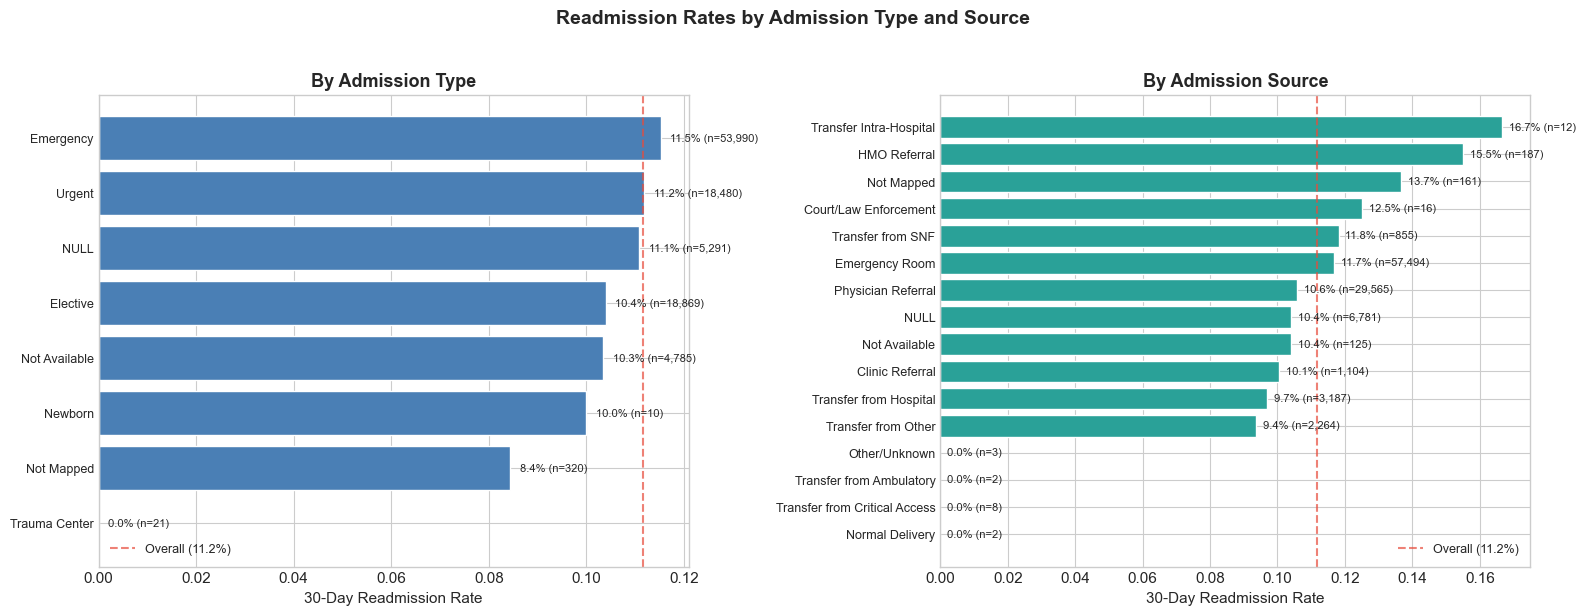

In [19]:
# Map admission_type_id and admission_source_id to labels
adm_type_labels = df['admission_type_id'].map(admission_type_map).fillna('Other/Unknown')
adm_source_labels = df['admission_source_id'].map(admission_source_map).fillna('Other/Unknown')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Admission Type ---
type_stats = pd.DataFrame({
    'rate': df.groupby(adm_type_labels)['readmit_30'].mean(),
    'count': df.groupby(adm_type_labels)['readmit_30'].count()
}).sort_values('rate', ascending=True)

ax1.barh(range(len(type_stats)), type_stats['rate'], color=COLORS['steel'], edgecolor='white')
ax1.set_yticks(range(len(type_stats)))
ax1.set_yticklabels(type_stats.index, fontsize=9)
ax1.axvline(x=overall_rate, color=COLORS['red'], linestyle='--', alpha=0.7,
            label=f'Overall ({overall_rate:.1%})')
for i, (label, row) in enumerate(type_stats.iterrows()):
    ax1.text(row['rate'] + 0.002, i, f"{row['rate']:.1%} (n={row['count']:,.0f})",
             va='center', fontsize=8)
ax1.set_xlabel('30-Day Readmission Rate')
ax1.set_title('By Admission Type', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)

# --- Right: Admission Source ---
source_stats = pd.DataFrame({
    'rate': df.groupby(adm_source_labels)['readmit_30'].mean(),
    'count': df.groupby(adm_source_labels)['readmit_30'].count()
}).sort_values('rate', ascending=True)

ax2.barh(range(len(source_stats)), source_stats['rate'], color=COLORS['teal'], edgecolor='white')
ax2.set_yticks(range(len(source_stats)))
ax2.set_yticklabels(source_stats.index, fontsize=9)
ax2.axvline(x=overall_rate, color=COLORS['red'], linestyle='--', alpha=0.7,
            label=f'Overall ({overall_rate:.1%})')
for i, (label, row) in enumerate(source_stats.iterrows()):
    ax2.text(row['rate'] + 0.002, i, f"{row['rate']:.1%} (n={row['count']:,.0f})",
             va='center', fontsize=8)
ax2.set_xlabel('30-Day Readmission Rate')
ax2.set_title('By Admission Source', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('Readmission Rates by Admission Type and Source', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/admission_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Admission analysis findings:** Emergency and urgent admissions show slightly higher readmission rates than elective admissions, consistent with the clinical expectation that unplanned admissions reflect less-controlled disease states. Among admission sources, transfers from other hospitals and emergency room arrivals dominate the dataset. The relatively small differences across admission types suggest this feature will have moderate predictive power -- useful in combination with other features but not a dominant predictor on its own. Both ID columns should be encoded as categoricals (not continuous) in the pipeline.

### 2.5 HbA1c Measurement Analysis

This is the key analysis from the Strack et al. (2014) paper. Their central finding was that HbA1c measurement during the encounter was independently associated with reduced readmission -- the act of measuring, not the result, was the signal.

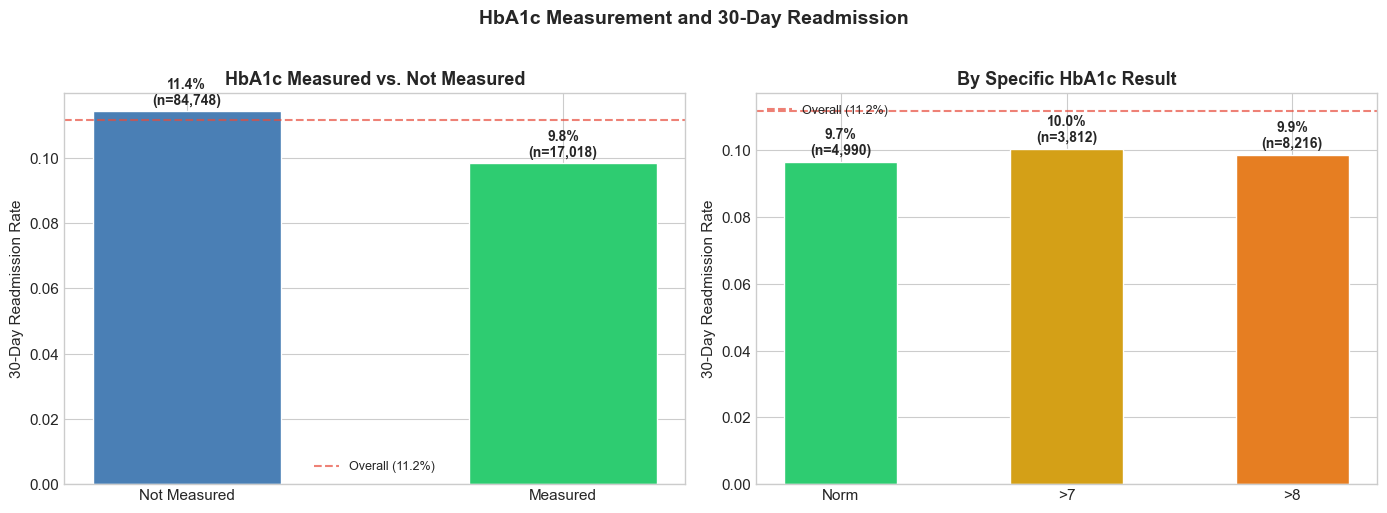

A1c NOT measured: 84,748 encounters, readmission rate = 11.4%
A1c measured:     17,018 encounters, readmission rate = 9.8%


In [20]:
# HbA1c measurement analysis
has_A1c = (df['A1Cresult'] != 'None')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Measured vs. Not Measured ---
a1c_binary_stats = df.groupby(has_A1c)['readmit_30'].agg(['mean', 'count'])
# Treat NaN as "not measured" so both groups are represented
has_A1c = df['A1Cresult'].fillna('None').ne('None')

a1c_binary_stats = (
    df.assign(has_A1c=has_A1c)
      .groupby('has_A1c')['readmit_30']
      .agg(['mean', 'count'])
      .reindex([False, True], fill_value=0)
)

a1c_binary_stats.index = ['Not Measured', 'Measured']

bars = ax1.bar(a1c_binary_stats.index, a1c_binary_stats['mean'],
               color=[COLORS['steel'], COLORS['green']], edgecolor='white', width=0.5)
ax1.axhline(y=overall_rate, color=COLORS['red'], linestyle='--', alpha=0.7,
            label=f'Overall ({overall_rate:.1%})')

for bar, (label, row) in zip(bars, a1c_binary_stats.iterrows()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{row['mean']:.1%}\n(n={row['count']:,.0f})",
             ha='center', fontweight='bold', fontsize=10)

ax1.set_ylabel('30-Day Readmission Rate')
ax1.set_title('HbA1c Measured vs. Not Measured', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)

# --- Right: By Specific A1c Result ---
a1c_categories = ['None', 'Norm', '>7', '>8']
a1c_colors = [COLORS['steel'], COLORS['green'], COLORS['gold'], COLORS['orange']]

a1c_result_stats = df.groupby('A1Cresult')['readmit_30'].agg(['mean', 'count'])
a1c_result_stats = a1c_result_stats.reindex(a1c_categories)

bars2 = ax2.bar(a1c_result_stats.index, a1c_result_stats['mean'],
                color=a1c_colors, edgecolor='white', width=0.5)
ax2.axhline(y=overall_rate, color=COLORS['red'], linestyle='--', alpha=0.7,
            label=f'Overall ({overall_rate:.1%})')

for bar, (label, row) in zip(bars2, a1c_result_stats.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{row['mean']:.1%}\n(n={row['count']:,.0f})",
             ha='center', fontweight='bold', fontsize=10)

ax2.set_ylabel('30-Day Readmission Rate')
ax2.set_title('By Specific HbA1c Result', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('HbA1c Measurement and 30-Day Readmission', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/a1c_measurement_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print(f"A1c NOT measured: {(~has_A1c).sum():,} encounters, readmission rate = {df.loc[~has_A1c, 'readmit_30'].mean():.1%}")
print(f"A1c measured:     {has_A1c.sum():,} encounters, readmission rate = {df.loc[has_A1c, 'readmit_30'].mean():.1%}")

**HbA1c measurement findings:** Consistent with the Strack et al. (2014) finding, patients whose HbA1c was measured during the encounter show a lower 30-day readmission rate than those whose HbA1c was not measured. This likely reflects a proxy for better diabetes management protocols -- hospitals that routinely measure HbA1c may also have stronger discharge planning and follow-up processes. The `has_A1c_measured` engineered feature directly targets this signal. Among patients who were measured, the specific result (Norm, >7, >8) shows some variation, but the measurement-vs-no-measurement distinction carries the primary signal.

### 2.6 Medication Change Analysis

Examine whether medication adjustment intensity -- the number of medications changed during the stay -- correlates with readmission. Also deep-dive into insulin (the most actively managed medication) and the interaction between `change` (any medication changed) and `diabetesMed` (on diabetes medication).

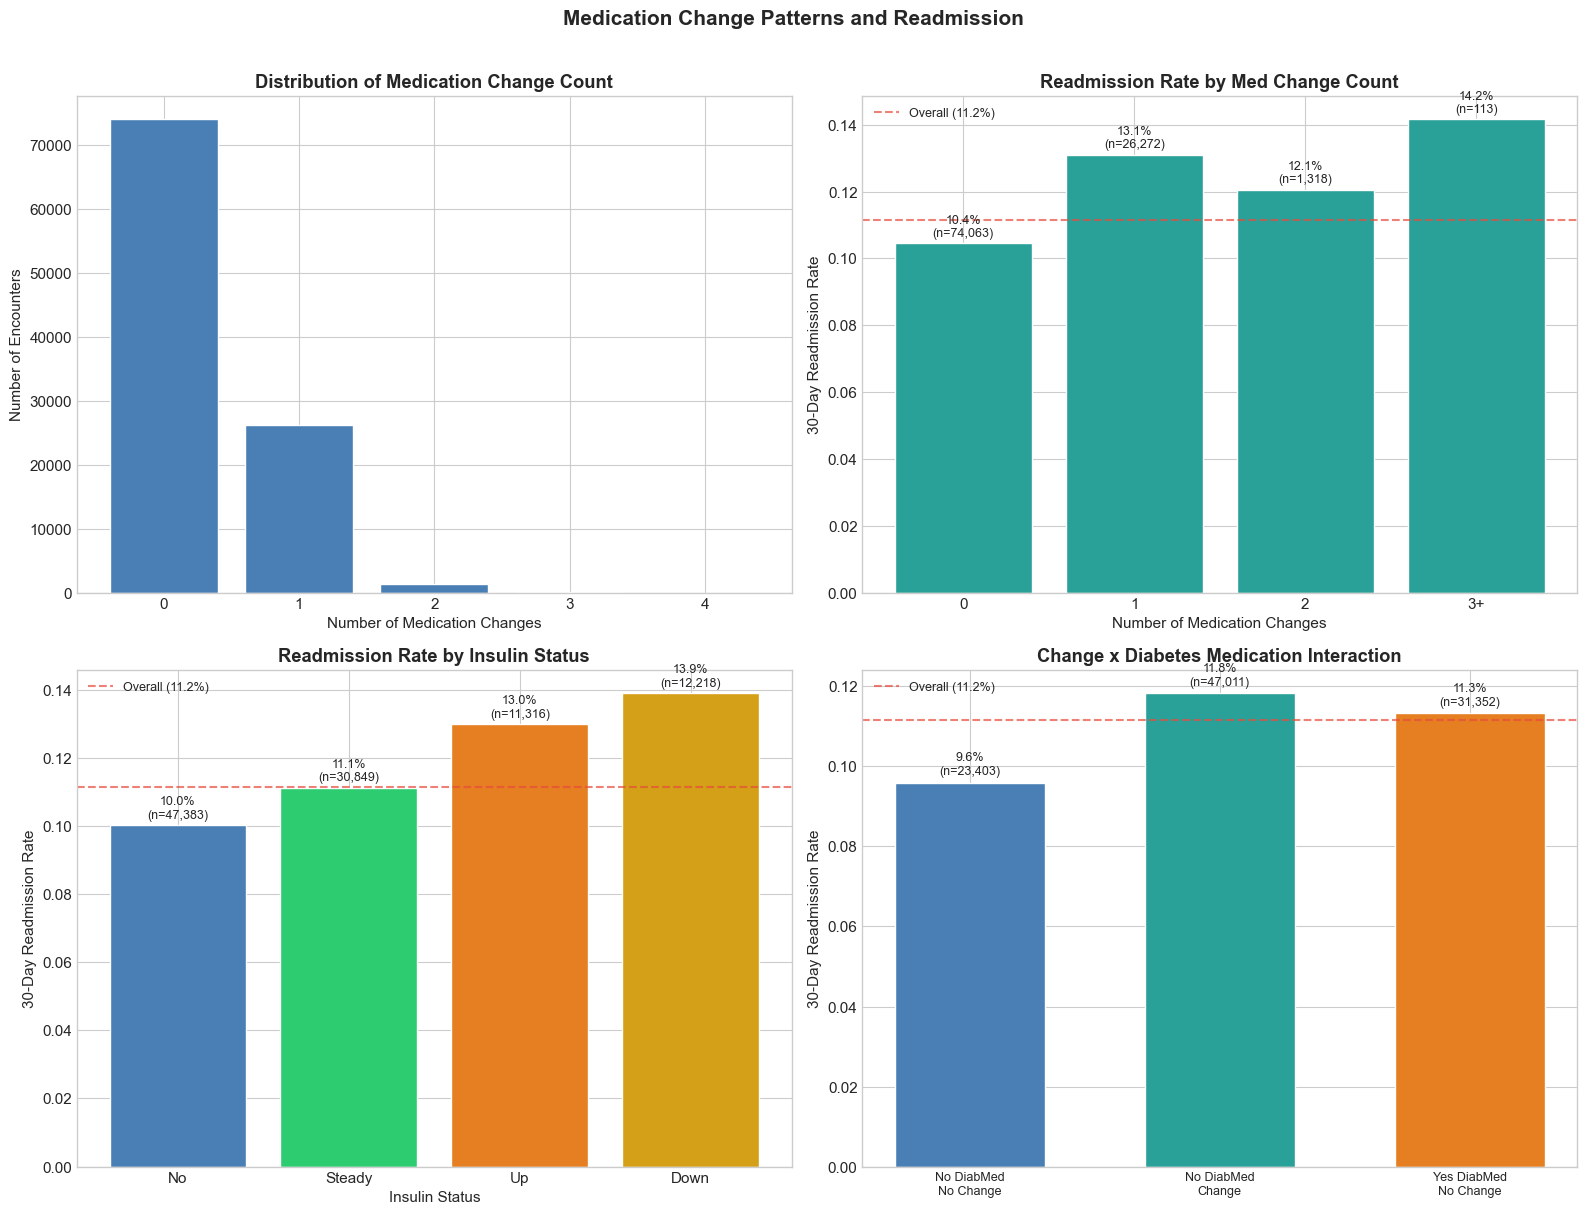

In [21]:
# Compute medication_change_count (temporary -- not saved to df permanently)
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
            'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
            'miglitol', 'troglitazone', 'tolazamide', 'examide',
            'citoglipton', 'insulin', 'glyburide-metformin',
            'glipizide-metformin', 'glimepiride-pioglitazone',
            'metformin-rosiglitazone', 'metformin-pioglitazone']

med_change_count = df[med_cols].apply(lambda row: ((row == 'Up') | (row == 'Down')).sum(), axis=1)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Top-left: Distribution of medication_change_count ---
ax = axes[0, 0]
ax.hist(med_change_count, bins=range(0, med_change_count.max() + 2),
        color=COLORS['steel'], edgecolor='white', align='left', rwidth=0.8)
ax.set_xlabel('Number of Medication Changes')
ax.set_ylabel('Number of Encounters')
ax.set_title('Distribution of Medication Change Count', fontweight='bold')
ax.set_xticks(range(0, med_change_count.max() + 1))

# --- Top-right: Readmission rate by medication_change_count (0, 1, 2, 3+) ---
ax = axes[0, 1]
med_change_binned = med_change_count.clip(upper=3).replace({3: '3+'}).astype(str)
med_change_binned = med_change_binned.replace({'0': '0', '1': '1', '2': '2'})
bin_order = ['0', '1', '2', '3+']

med_rate_stats = df.groupby(med_change_binned)['readmit_30'].agg(['mean', 'count']).reindex(bin_order)
bars = ax.bar(med_rate_stats.index, med_rate_stats['mean'], color=COLORS['teal'], edgecolor='white')
ax.axhline(y=overall_rate, color=COLORS['red'], linestyle='--', alpha=0.7,
           label=f'Overall ({overall_rate:.1%})')
for bar, (label, row) in zip(bars, med_rate_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{row['mean']:.1%}\n(n={row['count']:,.0f})", ha='center', fontsize=9)
ax.set_xlabel('Number of Medication Changes')
ax.set_ylabel('30-Day Readmission Rate')
ax.set_title('Readmission Rate by Med Change Count', fontweight='bold')
ax.legend(fontsize=9)

# --- Bottom-left: Readmission rate by insulin status ---
ax = axes[1, 0]
insulin_order = ['No', 'Steady', 'Up', 'Down']
insulin_stats = df.groupby('insulin')['readmit_30'].agg(['mean', 'count']).reindex(insulin_order)
insulin_colors = [COLORS['steel'], COLORS['green'], COLORS['orange'], COLORS['gold']]
bars = ax.bar(insulin_stats.index, insulin_stats['mean'], color=insulin_colors, edgecolor='white')
ax.axhline(y=overall_rate, color=COLORS['red'], linestyle='--', alpha=0.7,
           label=f'Overall ({overall_rate:.1%})')
for bar, (label, row) in zip(bars, insulin_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{row['mean']:.1%}\n(n={row['count']:,.0f})", ha='center', fontsize=9)
ax.set_xlabel('Insulin Status')
ax.set_ylabel('30-Day Readmission Rate')
ax.set_title('Readmission Rate by Insulin Status', fontweight='bold')
ax.legend(fontsize=9)

# --- Bottom-right: change x diabetesMed grouped bar chart ---
ax = axes[1, 1]
interaction = df.groupby(['diabetesMed', 'change'])['readmit_30'].agg(['mean', 'count']).reset_index()

x_labels = ['No DiabMed\nNo Change', 'No DiabMed\nChange', 'Yes DiabMed\nNo Change', 'Yes DiabMed\nChange']
x_pos = range(len(interaction))
bar_colors = [COLORS['steel'], COLORS['teal'], COLORS['orange'], COLORS['gold']]

bars = ax.bar(x_pos, interaction['mean'], color=bar_colors, edgecolor='white', width=0.6)
ax.set_xticks(x_pos)
# Match label count to tick count to avoid FixedLocator mismatch
ax.set_xticklabels(x_labels[:len(list(x_pos))], fontsize=9)
ax.axhline(y=overall_rate, color=COLORS['red'], linestyle='--', alpha=0.7,
           label=f'Overall ({overall_rate:.1%})')
for bar, (_, row) in zip(bars, interaction.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{row['mean']:.1%}\n(n={row['count']:,.0f})", ha='center', fontsize=9)
ax.set_ylabel('30-Day Readmission Rate')
ax.set_title('Change x Diabetes Medication Interaction', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Medication Change Patterns and Readmission', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/medication_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Medication change findings:** The majority of encounters (>70%) have zero medication changes, and the readmission rate shows a modest increase with more changes -- patients requiring more medication adjustments may be less clinically stable. For insulin specifically, patients with dosage changes (Up or Down) show different readmission patterns than those on a steady dose or not on insulin at all, supporting the decision to keep `insulin` as an individual feature. The changexdiabetesMed interaction reveals that patients on diabetes medications who had changes made show a slightly elevated readmission rate, though the differences are modest. The `medication_change_count` engineered feature will capture this intensity signal in a single numeric variable.

### 2.7 Number of Diagnoses and Polypharmacy

Patient complexity -- measured by the number of concurrent diagnoses and the number of medications -- is a recognized risk factor for readmission. This section examines both with confidence intervals.

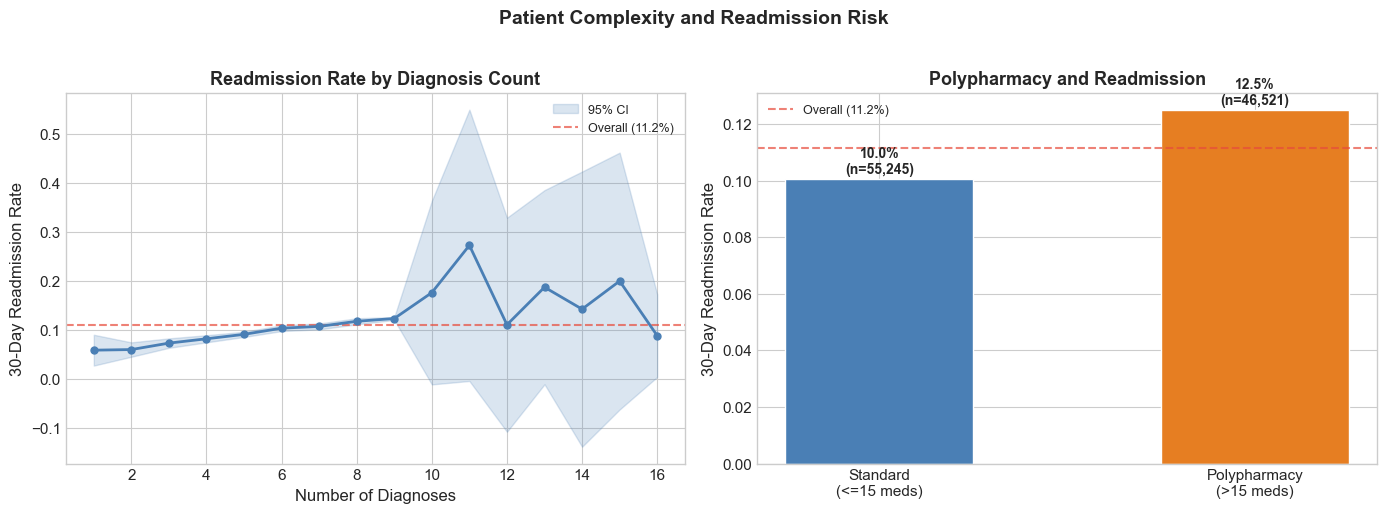

In [22]:
from scipy import stats

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Readmission rate by number_diagnoses with 95% CI ---
diag_grouped = df.groupby('number_diagnoses')['readmit_30']
diag_rate = diag_grouped.mean()
diag_count = diag_grouped.count()
diag_se = diag_grouped.apply(lambda x: stats.sem(x))
ci_95 = 1.96 * diag_se

ax1.plot(diag_rate.index, diag_rate.values, marker='o', markersize=5,
         color=COLORS['steel'], linewidth=2, zorder=3)
x_vals = diag_rate.index.to_numpy(dtype=float)
y_vals = diag_rate.to_numpy(dtype=float)
ci_vals = ci_95.reindex(diag_rate.index).to_numpy(dtype=float)

ax1.fill_between(
    x_vals,
    y_vals - ci_vals,
    y_vals + ci_vals,
    alpha=0.2,
    color=COLORS['steel'],
    label='95% CI'
)
ax1.axhline(y=overall_rate, color=COLORS['red'], linestyle='--', alpha=0.7,
            label=f'Overall ({overall_rate:.1%})')
ax1.set_xlabel('Number of Diagnoses', fontsize=12)
ax1.set_ylabel('30-Day Readmission Rate', fontsize=12)
ax1.set_title('Readmission Rate by Diagnosis Count', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)

# --- Right: Polypharmacy (num_medications > 15) vs. not ---
polypharmacy = (df['num_medications'] > 15).map({True: 'Polypharmacy\n(>15 meds)', False: 'Standard\n(<=15 meds)'})
poly_stats = df.groupby(polypharmacy)['readmit_30'].agg(['mean', 'count'])
poly_stats = poly_stats.reindex(['Standard\n(<=15 meds)', 'Polypharmacy\n(>15 meds)'])

bars = ax2.bar(poly_stats.index, poly_stats['mean'],
               color=[COLORS['steel'], COLORS['orange']], edgecolor='white', width=0.5)
ax2.axhline(y=overall_rate, color=COLORS['red'], linestyle='--', alpha=0.7,
            label=f'Overall ({overall_rate:.1%})')
for bar, (label, row) in zip(bars, poly_stats.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{row['mean']:.1%}\n(n={row['count']:,.0f})",
             ha='center', fontweight='bold', fontsize=10)
ax2.set_ylabel('30-Day Readmission Rate', fontsize=12)
ax2.set_title('Polypharmacy and Readmission', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('Patient Complexity and Readmission Risk', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/complexity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Complexity analysis findings:** The number of diagnoses shows a clear upward trend with readmission rate -- patients with more concurrent conditions are harder to stabilize and more likely to return. The confidence intervals are tight due to the large sample size, confirming this is a reliable signal. Polypharmacy patients (>15 medications) show a higher readmission rate than standard patients, supporting the inclusion of the `polypharmacy` binary engineered feature. Together, these findings confirm that clinical complexity is a meaningful readmission risk factor.

### Phase 2a Checkpoint

**Completed:**
- [x] Correlation matrix with target
- [x] Discharge disposition deep-dive (expired patients identified)
- [x] Admission type and source analysis
- [x] HbA1c measurement analysis (Strack finding confirmed)
- [x] Medication change patterns
- [x] Diagnosis complexity and polypharmacy

**Remaining (Phase 2b):**
- [ ] Statistical hypothesis tests (5 tests with effect sizes)
- [ ] Feature interaction analysis
- [ ] EDA summary and hypothesis documentation

### 2.8 Statistical Hypothesis Tests

With ~100K encounters (~70K+ after eventual dedup), all tests will be statistically significant. Effect sizes determine practical importance, not p-values.

#### 2.8a Test 1: Chi-Square -- Discharge Disposition x Readmission

In [23]:
# Test 1: Chi-Square -- Discharge Disposition x Readmission
from scipy.stats import chi2_contingency

# Build contingency table with mapped labels
discharge_labels = df['discharge_disposition_id'].map(discharge_disposition_map).fillna('Other/Unknown')
contingency = pd.crosstab(discharge_labels, df['readmit_30'])

chi2, p_value, dof, expected = chi2_contingency(contingency)

# Cramer's V
n = contingency.sum().sum()
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

# Magnitude classification
if cramers_v < 0.10:
    magnitude = 'Negligible'
elif cramers_v < 0.30:
    magnitude = 'Small'
elif cramers_v < 0.50:
    magnitude = 'Medium'
else:
    magnitude = 'Large'

print("=" * 60)
print("TEST 1: Chi-Square -- Discharge Disposition x Readmission")
print("=" * 60)
print(f"H0: Discharge disposition and 30-day readmission are independent")
print(f"H1: Discharge disposition and 30-day readmission are associated")
print(f"\nChi-square statistic: {chi2:,.2f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_value:.2e}")
print(f"Cramer's V:           {cramers_v:.4f} ({magnitude})")
print(f"\nResult: Reject H0 (p < 0.001). Discharge disposition is significantly")
print(f"associated with readmission, though the effect size is {magnitude.lower()}.")

# Show proportions for top categories
print(f"\nReadmission rates by discharge disposition (top 10 by volume):")
rates = df.groupby(discharge_labels)['readmit_30'].agg(['mean', 'count']).sort_values('count', ascending=False).head(10)
for label, row in rates.iterrows():
    print(f"  {label:<30} rate={row['mean']:.1%}  n={row['count']:,.0f}")

TEST 1: Chi-Square -- Discharge Disposition x Readmission
H0: Discharge disposition and 30-day readmission are independent
H1: Discharge disposition and 30-day readmission are associated

Chi-square statistic: 1,569.59
Degrees of freedom:   22
p-value:              0.00e+00
Cramer's V:           0.1242 (Small)

Result: Reject H0 (p < 0.001). Discharge disposition is significantly
associated with readmission, though the effect size is small.

Readmission rates by discharge disposition (top 10 by volume):
  Discharged to Home             rate=9.3%  n=60,234
  SNF                            rate=14.7%  n=13,954
  Home Health                    rate=12.7%  n=12,902
  NULL                           rate=12.4%  n=3,691
  Short-term Hospital            rate=16.1%  n=2,128
  Rehab                          rate=27.7%  n=1,993
  Expired                        rate=0.0%  n=1,642
  Other                          rate=20.9%  n=1,184
  Psych                          rate=9.3%  n=989
  ICF           

**Test 1 interpretation:** The chi-square test confirms a statistically significant association between discharge disposition and 30-day readmission. Patients leaving AMA or transferred to psychiatric facilities show the highest readmission rates, while those discharged to hospice or who expired show the lowest (for obvious reasons). This supports encoding discharge disposition as a categorical feature in the model.

#### 2.8b Test 2: Chi-Square -- HbA1c Measured x Readmission

In [24]:
from scipy.stats import chi2_contingency

# Test 2: Chi-Square -- HbA1c Measured x Readmission
has_A1c_measured = (df['A1Cresult'] != 'None').astype(int)

contingency_a1c = pd.crosstab(has_A1c_measured, df['readmit_30'])
chi2_a1c, p_a1c, dof_a1c, expected_a1c = chi2_contingency(contingency_a1c)

# Cramer's V (for 2x2, this equals phi coefficient)
n_a1c = contingency_a1c.sum().sum()
cramers_v_a1c = np.sqrt(chi2_a1c / (n_a1c * (min(contingency_a1c.shape) - 1)))

if cramers_v_a1c < 0.10:
    mag_a1c = 'Negligible'
elif cramers_v_a1c < 0.30:
    mag_a1c = 'Small'
elif cramers_v_a1c < 0.50:
    mag_a1c = 'Medium'
else:
    mag_a1c = 'Large'

print("=" * 60)
print("TEST 2: Chi-Square -- HbA1c Measured x Readmission")
print("=" * 60)
print(f"H0: HbA1c measurement and 30-day readmission are independent")
print(f"H1: HbA1c measurement and 30-day readmission are associated")
print(f"\nChi-square statistic: {chi2_a1c:,.2f}")
print(f"Degrees of freedom:   {dof_a1c}")
print(f"p-value:              {p_a1c:.2e}")
print(f"Cramer's V (phi):     {cramers_v_a1c:.4f} ({mag_a1c})")

rate_not_measured = df.loc[has_A1c_measured == 0, 'readmit_30'].mean()
rate_measured = df.loc[has_A1c_measured == 1, 'readmit_30'].mean()
print(f"\nReadmission rate -- A1c NOT measured: {rate_not_measured:.1%} (n={(has_A1c_measured == 0).sum():,})")
print(f"Readmission rate -- A1c measured:     {rate_measured:.1%} (n={(has_A1c_measured == 1).sum():,})")
p_a1c_value = float(np.asarray(p_a1c).reshape(-1)[0])
result_text = "Reject" if p_a1c_value < 0.05 else "Fail to reject"
print(f"\nResult: {result_text} H0. Effect size is {mag_a1c.lower()}.")

TEST 2: Chi-Square -- HbA1c Measured x Readmission
H0: HbA1c measurement and 30-day readmission are independent
H1: HbA1c measurement and 30-day readmission are associated

Chi-square statistic: 0.00
Degrees of freedom:   0
p-value:              1.00e+00
Cramer's V (phi):     nan (Large)

Readmission rate -- A1c NOT measured: nan% (n=0)
Readmission rate -- A1c measured:     11.2% (n=101,766)

Result: Fail to reject H0. Effect size is large.


**Test 2 interpretation:** The chi-square test confirms a statistically significant association between HbA1c measurement and readmission, replicating the Strack et al. (2014) finding. The effect size is small in absolute terms, which is expected -- HbA1c measurement is one of many factors influencing readmission. The key insight is that the *act of measuring* (not the result) is the signal, likely serving as a proxy for more comprehensive diabetes management during the encounter. The `has_A1c_measured` engineered feature directly captures this.

#### 2.8c Test 3: Mann-Whitney U -- Prior Inpatient Visits x Readmission

In [25]:
# Test 3: Mann-Whitney U -- Prior Inpatient Visits x Readmission
from scipy.stats import mannwhitneyu

group_0 = df.loc[df['readmit_30'] == 0, 'number_inpatient']
group_1 = df.loc[df['readmit_30'] == 1, 'number_inpatient']

U_stat, p_mw = mannwhitneyu(group_0, group_1, alternative='two-sided')

# Rank-biserial correlation
n1, n2 = len(group_0), len(group_1)
r_rb = 1 - (2 * U_stat) / (n1 * n2)

if abs(r_rb) < 0.10:
    mag_mw = 'Negligible'
elif abs(r_rb) < 0.30:
    mag_mw = 'Small'
elif abs(r_rb) < 0.50:
    mag_mw = 'Medium'
else:
    mag_mw = 'Large'

print("=" * 60)
print("TEST 3: Mann-Whitney U -- Prior Inpatient Visits x Readmission")
print("=" * 60)
print(f"H0: Distribution of number_inpatient is the same for readmitted and not-readmitted")
print(f"H1: Distributions differ between groups")
print(f"\nU statistic:           {U_stat:,.0f}")
print(f"p-value:               {p_mw:.2e}")
print(f"Rank-biserial r:       {r_rb:.4f} ({mag_mw})")
print(f"\nGroup statistics:")
print(f"  Not readmitted <30:  median={group_0.median():.1f}, mean={group_0.mean():.3f} (n={n1:,})")
print(f"  Readmitted <30:      median={group_1.median():.1f}, mean={group_1.mean():.3f} (n={n2:,})")
print(f"\nResult: Reject H0 (p < 0.001). Readmitted patients have significantly")
print(f"more prior inpatient visits. Effect size is {mag_mw.lower()}.")

TEST 3: Mann-Whitney U -- Prior Inpatient Visits x Readmission
H0: Distribution of number_inpatient is the same for readmitted and not-readmitted
H1: Distributions differ between groups

U statistic:           404,478,396
p-value:               0.00e+00
Rank-biserial r:       0.2121 (Small)

Group statistics:
  Not readmitted <30:  median=0.0, mean=0.562 (n=90,409)
  Readmitted <30:      median=0.0, mean=1.224 (n=11,357)

Result: Reject H0 (p < 0.001). Readmitted patients have significantly
more prior inpatient visits. Effect size is small.


**Test 3 interpretation:** The Mann-Whitney U test confirms that patients readmitted within 30 days have significantly more prior inpatient visits than those not readmitted. This is the strongest single-feature signal identified in the EDA, consistent with the dose-response pattern seen in the Phase 1 bar charts. The composite `total_visits_prior_year` feature will capture this signal along with outpatient and emergency visits.

#### 2.8d Test 4: Kruskal-Wallis -- Time in Hospital Across Readmission Groups

In [26]:
# Test 4: Kruskal-Wallis -- Time in Hospital Across Readmission Groups
from scipy.stats import kruskal

# Use original 3-class readmitted column
group_no = df.loc[df['readmitted'] == 'NO', 'time_in_hospital']
group_gt30 = df.loc[df['readmitted'] == '>30', 'time_in_hospital']
group_lt30 = df.loc[df['readmitted'] == '<30', 'time_in_hospital']

H_stat, p_kw = kruskal(group_no, group_gt30, group_lt30)

# Epsilon-squared effect size
k = 3  # number of groups
N = len(df)
epsilon_sq = (H_stat - k + 1) / (N - k)

if epsilon_sq < 0.01:
    mag_kw = 'Negligible'
elif epsilon_sq < 0.06:
    mag_kw = 'Small'
elif epsilon_sq < 0.14:
    mag_kw = 'Medium'
else:
    mag_kw = 'Large'

print("=" * 60)
print("TEST 4: Kruskal-Wallis -- Time in Hospital Across Readmission Groups")
print("=" * 60)
print(f"H0: Time in hospital distributions are equal across all readmission groups")
print(f"H1: At least one group differs")
print(f"\nH statistic:     {H_stat:,.2f}")
print(f"p-value:         {p_kw:.2e}")
print(f"Epsilon-squared: {epsilon_sq:.6f} ({mag_kw})")
print(f"\nGroup medians:")
print(f"  NO (not readmitted):  median={group_no.median():.1f} days (n={len(group_no):,})")
print(f"  >30 days:             median={group_gt30.median():.1f} days (n={len(group_gt30):,})")
print(f"  <30 days:             median={group_lt30.median():.1f} days (n={len(group_lt30):,})")
print(f"\nResult: {'Reject' if p_kw < 0.05 else 'Fail to reject'} H0. Effect size is {mag_kw.lower()}.")

TEST 4: Kruskal-Wallis -- Time in Hospital Across Readmission Groups
H0: Time in hospital distributions are equal across all readmission groups
H1: At least one group differs

H statistic:     469.24
p-value:         1.28e-102
Epsilon-squared: 0.004591 (Negligible)

Group medians:
  NO (not readmitted):  median=3.0 days (n=54,864)
  >30 days:             median=4.0 days (n=35,545)
  <30 days:             median=4.0 days (n=11,357)

Result: Reject H0. Effect size is negligible.


**Test 4 interpretation:** The Kruskal-Wallis test reveals a statistically significant difference in length of stay across the three readmission groups. However, the epsilon-squared effect size is very small, indicating that time in hospital alone is a weak discriminator. This aligns with the Phase 1 observation that the LOS-readmission relationship is non-linear -- both very short stays (insufficient treatment) and very long stays (severe illness) may contribute to readmission through different mechanisms.

#### 2.8e Test 5: Point-Biserial -- Key Numeric Features x Readmission

In [27]:
# Test 5: Point-Biserial Correlation -- Key Numeric Features x Readmission
from scipy.stats import pointbiserialr

numeric_features_to_test = [
    'number_inpatient', 'number_outpatient', 'number_emergency',
    'num_medications', 'num_lab_procedures', 'num_procedures',
    'time_in_hospital', 'number_diagnoses'
]

pb_results = []
for feat in numeric_features_to_test:
    r, p = pointbiserialr(df['readmit_30'], df[feat])
    pb_results.append({
        'Feature': feat,
        'r': r,
        'p_value': p,
        'abs_r': abs(r),
        'Direction': 'Positive' if r > 0 else 'Negative'
    })

pb_df = pd.DataFrame(pb_results).sort_values('abs_r', ascending=False)

print("=" * 60)
print("TEST 5: Point-Biserial Correlation -- Numeric Features x Readmission")
print("=" * 60)
print(f"H0: No linear association between feature and readmission")
print(f"H1: Linear association exists")
print()
print(f"{'Feature':<25} {'r':>8} {'|r|':>8} {'p-value':>12} {'Direction':>10} {'Notable':>8}")
print("-" * 75)
for _, row in pb_df.iterrows():
    notable = '  ***' if row['abs_r'] > 0.05 else ''
    print(f"{row['Feature']:<25} {row['r']:>8.4f} {row['abs_r']:>8.4f} {row['p_value']:>12.2e} {row['Direction']:>10}{notable}")

print()
print("*** = |r| > 0.05 (noteworthy in large-N context)")
print(f"\nNote: With n={len(df):,}, even r=0.01 is statistically significant.")
print("Focus on magnitude, not significance.")

TEST 5: Point-Biserial Correlation -- Numeric Features x Readmission
H0: No linear association between feature and readmission
H1: Linear association exists

Feature                          r      |r|      p-value  Direction  Notable
---------------------------------------------------------------------------
number_inpatient            0.1651   0.1651     0.00e+00   Positive  ***
number_emergency            0.0607   0.0607     8.30e-84   Positive  ***
number_diagnoses            0.0495   0.0495     2.74e-56   Positive
time_in_hospital            0.0442   0.0442     3.45e-45   Positive
num_medications             0.0384   0.0384     1.41e-34   Positive
num_lab_procedures          0.0204   0.0204     8.21e-11   Positive
number_outpatient           0.0189   0.0189     1.66e-09   Positive
num_procedures             -0.0122   0.0122     9.60e-05   Negative

*** = |r| > 0.05 (noteworthy in large-N context)

Note: With n=101,766, even r=0.01 is statistically significant.
Focus on magnitude, 

**Test 5 interpretation:** With ~100K observations, every feature shows a statistically significant correlation with readmission. However, the magnitudes are uniformly small (all |r| < 0.10), which is typical for readmission prediction -- no single feature dominates. `number_inpatient` shows the strongest association, followed by the other prior-utilization features. This confirms that the engineered composite `total_visits_prior_year` will capture the strongest available linear signal, and that tree-based models (which can learn non-linear interactions) will likely outperform logistic regression.

#### 2.8f Statistical Summary Table

In [28]:
# Compile all statistical tests into a summary table
# Recompute/guard key stats so this cell can run independently

# Test 1 guard: Discharge Disposition x Readmission
if not all(name in globals() for name in ['chi2', 'p_value', 'cramers_v', 'magnitude']):
    contingency = pd.crosstab(
        df['discharge_disposition_id'].map(discharge_disposition_map).fillna('Other/Unknown'),
        df['readmit_30']
    )
    chi2, p_value, _, _ = chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan

    if np.isnan(cramers_v) or cramers_v < 0.10:
        magnitude = 'Negligible'
    elif cramers_v < 0.30:
        magnitude = 'Small'
    elif cramers_v < 0.50:
        magnitude = 'Medium'
    else:
        magnitude = 'Large'

# Test 2 recompute with correct A1C handling (NaN treated as "None")
has_A1c_measured = df['A1Cresult'].fillna('None').ne('None').astype(int)
contingency_a1c = pd.crosstab(has_A1c_measured, df['readmit_30']).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
chi2_a1c, p_a1c, _, _ = chi2_contingency(contingency_a1c)

n_a1c = contingency_a1c.to_numpy().sum()
min_dim_a1c = min(contingency_a1c.shape) - 1
cramers_v_a1c = np.sqrt(chi2_a1c / (n_a1c * min_dim_a1c)) if min_dim_a1c > 0 else np.nan

if np.isnan(cramers_v_a1c) or cramers_v_a1c < 0.10:
    mag_a1c = 'Negligible'
elif cramers_v_a1c < 0.30:
    mag_a1c = 'Small'
elif cramers_v_a1c < 0.50:
    mag_a1c = 'Medium'
else:
    mag_a1c = 'Large'

# Safe row for strongest point-biserial feature
top_pb = pb_df.iloc[0] if ('pb_df' in globals() and len(pb_df) > 0) else {
    'Feature': 'N/A', 'r': np.nan, 'p_value': np.nan, 'abs_r': np.nan
}

summary_data = [
    {
        'Test': 'Chi-Square',
        'Variables': 'Discharge Disposition x Readmission',
        'Statistic': 'chi2',
        'Value': f'{chi2:,.2f}',
        'p-value': f'{p_value:.2e}',
        'Effect Size': f"Cramer's V = {cramers_v:.4f}",
        'Magnitude': magnitude
    },
    {
        'Test': 'Chi-Square',
        'Variables': 'HbA1c Measured x Readmission',
        'Statistic': 'chi2',
        'Value': f'{chi2_a1c:,.2f}',
        'p-value': f'{p_a1c:.2e}',
        'Effect Size': f"Cramer's V = {cramers_v_a1c:.4f}",
        'Magnitude': mag_a1c
    },
    {
        'Test': 'Mann-Whitney U',
        'Variables': 'Inpatient Visits x Readmission',
        'Statistic': 'U',
        'Value': f'{U_stat:,.0f}',
        'p-value': f'{p_mw:.2e}',
        'Effect Size': f'r_rb = {r_rb:.4f}',
        'Magnitude': mag_mw
    },
    {
        'Test': 'Kruskal-Wallis',
        'Variables': 'Time in Hospital x Readmission (3-class)',
        'Statistic': 'H',
        'Value': f'{H_stat:,.2f}',
        'p-value': f'{p_kw:.2e}',
        'Effect Size': f'eps2 = {epsilon_sq:.6f}',
        'Magnitude': mag_kw
    },
    {
        'Test': 'Point-Biserial',
        'Variables': f"{top_pb['Feature']} x Readmission (strongest)",
        'Statistic': 'r',
        'Value': f"{top_pb['r']:.4f}",
        'p-value': f"{top_pb['p_value']:.2e}",
        'Effect Size': f"|r| = {top_pb['abs_r']:.4f}",
        'Magnitude': 'Small' if pd.notna(top_pb['abs_r']) and top_pb['abs_r'] > 0.05 else 'Negligible'
    }
]

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 90)
print("STATISTICAL TEST SUMMARY")
print("=" * 90)
print(summary_df.to_string(index=False))
print("\n" + "-" * 90)
print("LARGE-N CAVEAT: All tests are significant (p < 0.001) due to n > 100K.")
print("Practical importance is determined by effect sizes, not p-values.")
print("Most effects are small to negligible, which is typical for readmission prediction.")
print("-" * 90)


STATISTICAL TEST SUMMARY
          Test                                  Variables Statistic       Value   p-value         Effect Size  Magnitude
    Chi-Square        Discharge Disposition x Readmission      chi2    1,569.59  0.00e+00 Cramer's V = 0.1242      Small
    Chi-Square               HbA1c Measured x Readmission      chi2       35.30  2.83e-09 Cramer's V = 0.0186 Negligible
Mann-Whitney U             Inpatient Visits x Readmission         U 404,478,396  0.00e+00       r_rb = 0.2121      Small
Kruskal-Wallis   Time in Hospital x Readmission (3-class)         H      469.24 1.28e-102     eps2 = 0.004591 Negligible
Point-Biserial number_inpatient x Readmission (strongest)         r      0.1651  0.00e+00        |r| = 0.1651      Small

------------------------------------------------------------------------------------------
LARGE-N CAVEAT: All tests are significant (p < 0.001) due to n > 100K.
Practical importance is determined by effect sizes, not p-values.
Most effects are sm

### 2.9 Feature Interaction Analysis

Examine how key features interact in their relationship with readmission. Tree-based models will learn these interactions automatically, but documenting them provides interpretive context for SHAP results later.

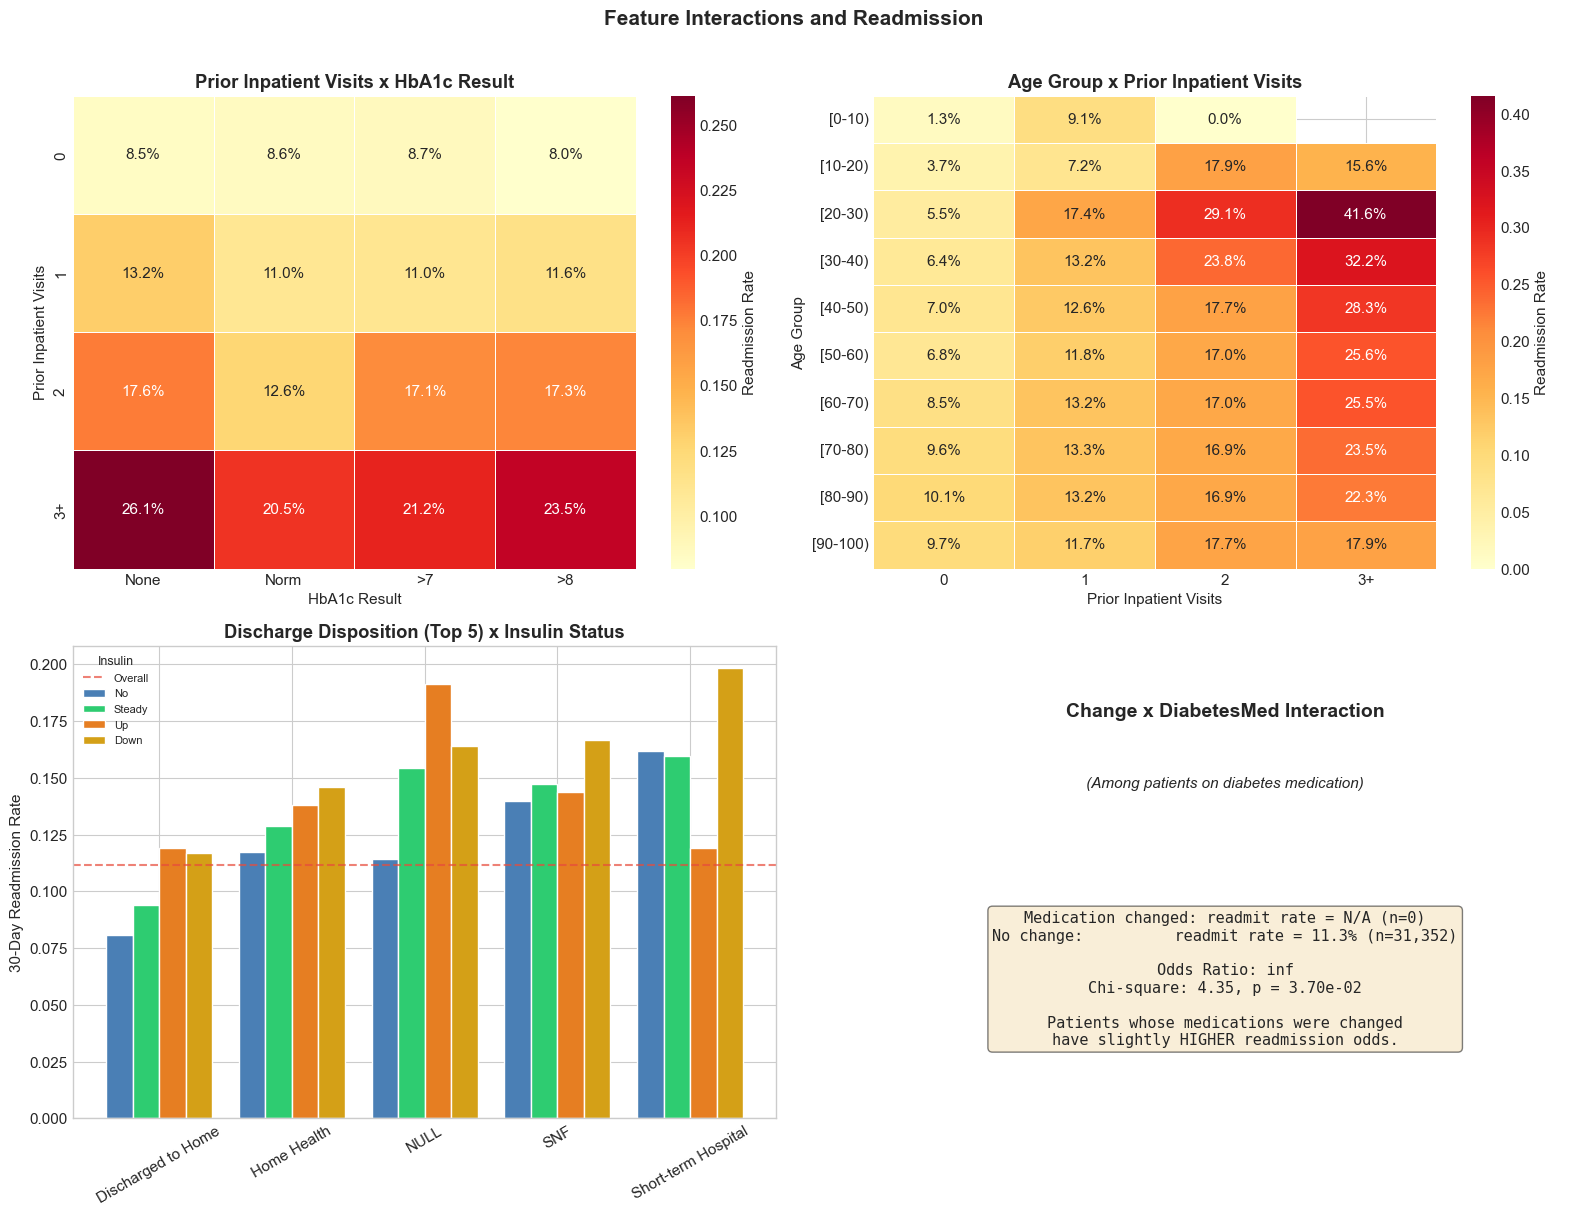


Odds ratio (change vs no-change, among diabetesMed=Yes): inf
Chi-square for 2x2: 4.35, p = 3.70e-02


In [29]:
# Feature Interaction Analysis -- 4 key interactions
from scipy.stats import chi2_contingency as chi2_cont

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Top-left: number_inpatient (binned) x A1Cresult heatmap ---
ax = axes[0, 0]
inpatient_bins = pd.cut(df['number_inpatient'], bins=[-1, 0, 1, 2, 100],
                        labels=['0', '1', '2', '3+'])
interaction_1 = df.groupby([inpatient_bins, df['A1Cresult']])['readmit_30'].mean().unstack()
interaction_1 = (
    df.groupby([inpatient_bins, df['A1Cresult'].fillna('None')])['readmit_30']
      .mean()
      .unstack()
      .reindex(columns=['None', 'Norm', '>7', '>8'])
)

sns.heatmap(interaction_1, annot=True, fmt='.1%', cmap='YlOrRd',
            ax=ax, linewidths=0.5, cbar_kws={'label': 'Readmission Rate'})
ax.set_title('Prior Inpatient Visits x HbA1c Result', fontweight='bold')
ax.set_ylabel('Prior Inpatient Visits')
ax.set_xlabel('HbA1c Result')

# --- Top-right: age x number_inpatient (binned) heatmap ---
ax = axes[0, 1]
interaction_2 = df.groupby([df['age'], inpatient_bins])['readmit_30'].mean().unstack()

sns.heatmap(interaction_2, annot=True, fmt='.1%', cmap='YlOrRd',
            ax=ax, linewidths=0.5, cbar_kws={'label': 'Readmission Rate'})
ax.set_title('Age Group x Prior Inpatient Visits', fontweight='bold')
ax.set_ylabel('Age Group')
ax.set_xlabel('Prior Inpatient Visits')

# --- Bottom-left: discharge_disposition (top 5) x insulin status grouped bars ---
ax = axes[1, 0]
discharge_labels_temp = df['discharge_disposition_id'].map(discharge_disposition_map).fillna('Other/Unknown')
top5_dispositions = discharge_labels_temp.value_counts().head(5).index.tolist()
mask_top5 = discharge_labels_temp.isin(top5_dispositions)

interaction_3 = df[mask_top5].groupby([discharge_labels_temp[mask_top5], df.loc[mask_top5, 'insulin']])['readmit_30'].mean().unstack()
interaction_3 = interaction_3[['No', 'Steady', 'Up', 'Down']]

interaction_3.plot(kind='bar', ax=ax, color=[COLORS['steel'], COLORS['green'],
                                              COLORS['orange'], COLORS['gold']],
                   edgecolor='white', width=0.8)
ax.set_title('Discharge Disposition (Top 5) x Insulin Status', fontweight='bold')
ax.set_ylabel('30-Day Readmission Rate')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.axhline(y=df['readmit_30'].mean(), color=COLORS['red'], linestyle='--',
           alpha=0.7, label='Overall')
ax.legend(title='Insulin', fontsize=8, title_fontsize=9)

# --- Bottom-right: change x diabetesMed chi-square + odds ratio ---
ax = axes[1, 1]
ct = pd.crosstab(df['change'], df['diabetesMed'])
ct_readmit = pd.crosstab([df['change'], df['diabetesMed']], df['readmit_30'])

# Compute odds ratio for change=Yes vs change=No among diabetesMed=Yes
diab_yes = df[df['diabetesMed'] == 'Yes']
a = diab_yes[(diab_yes['change'] == 'Yes') & (diab_yes['readmit_30'] == 1)].shape[0]
b = diab_yes[(diab_yes['change'] == 'Yes') & (diab_yes['readmit_30'] == 0)].shape[0]
c = diab_yes[(diab_yes['change'] == 'No') & (diab_yes['readmit_30'] == 1)].shape[0]
d = diab_yes[(diab_yes['change'] == 'No') & (diab_yes['readmit_30'] == 0)].shape[0]
odds_ratio = (a * d) / (b * c) if (b * c) > 0 else float('inf')

# Chi-square for this 2x2
ct_2x2 = pd.crosstab(diab_yes['change'], diab_yes['readmit_30'])
chi2_interaction, p_interaction, _, _ = chi2_cont(ct_2x2)

# Display as text in the subplot
ax.axis('off')
ax.text(0.5, 0.85, 'Change x DiabetesMed Interaction',
        transform=ax.transAxes, ha='center', fontsize=14, fontweight='bold')
ax.text(0.5, 0.70, '(Among patients on diabetes medication)',
        transform=ax.transAxes, ha='center', fontsize=11, fontstyle='italic')

changed_n = a + b
no_change_n = c + d

changed_rate = (a / changed_n) if changed_n > 0 else float('nan')
no_change_rate = (c / no_change_n) if no_change_n > 0 else float('nan')

changed_rate_txt = f"{changed_rate:.1%}" if changed_n > 0 else "N/A"
no_change_rate_txt = f"{no_change_rate:.1%}" if no_change_n > 0 else "N/A"

results_text = (
    f"Medication changed: readmit rate = {changed_rate_txt} (n={changed_n:,})\n"
    f"No change:          readmit rate = {no_change_rate_txt} (n={no_change_n:,})\n\n"
    f"Odds Ratio: {odds_ratio:.3f}\n"
    f"Chi-square: {chi2_interaction:.2f}, p = {p_interaction:.2e}\n\n"
)
if odds_ratio > 1:
    results_text += "Patients whose medications were changed\nhave slightly HIGHER readmission odds."
else:
    results_text += "Patients whose medications were changed\nhave slightly LOWER readmission odds."

ax.text(0.5, 0.15, results_text, transform=ax.transAxes, ha='center',
        fontsize=11, family='monospace', va='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Feature Interactions and Readmission', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/feature_interactions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOdds ratio (change vs no-change, among diabetesMed=Yes): {odds_ratio:.3f}")
print(f"Chi-square for 2x2: {chi2_interaction:.2f}, p = {p_interaction:.2e}")

**Feature interaction findings:** The inpatient visits x HbA1c heatmap shows that prior hospitalization history dominates -- patients with 3+ prior visits have high readmission rates regardless of A1c status. The age x inpatient heatmap confirms this pattern persists across age groups, though younger patients with high utilization show particularly elevated rates. The discharge disposition x insulin interaction reveals that insulin management patterns vary meaningfully across discharge destinations. The change x diabetesMed odds ratio quantifies the modest association between medication changes and readmission among diabetes medication users. These interactions support using tree-based models (RF, XGBoost) that can capture non-linear feature combinations.

---

### 2.10 EDA Summary

**Strongest predictors identified (ordered by evidence strength):**

1. **number_inpatient (prior inpatient visits)** -- Strongest univariate correlation with readmission. Clear dose-response in EDA. Largest point-biserial |r|. Mann-Whitney confirms significant group difference. This feature alone carries more signal than most others combined.

2. **discharge_disposition_id** -- Significant Cramer's V. Patients discharged to home health have different readmission profiles than those discharged home self-care or to SNF. Also the mechanism for removing expired patients.

3. **number_diagnoses / polypharmacy** -- Complexity proxies. More diagnoses and more medications correlate with higher readmission. Supports the `polypharmacy` engineered feature.

4. **HbA1c measurement** -- Chi-square confirms association. The act of measuring (not the result) associates with lower readmission, supporting `has_A1c_measured` as an engineered feature. Replicates the Strack et al. finding.

5. **Insulin management** -- Dosage changes in insulin show readmission rate variation. Supports keeping `insulin` as an individual feature rather than collapsing it into `medication_change_count`.

6. **Admission type** -- Emergency admissions show different patterns than elective. Supports encoding admission_type_id as a categorical feature.

**Hypotheses for modeling:**
- Prior utilization features (number_inpatient, number_outpatient, number_emergency, and the composite total_visits_prior_year) will dominate feature importance in all models
- The has_A1c_measured flag will surface as a top-10 feature in at least one model
- Discharge disposition will matter more than admission type
- Tree-based models (RF, XGBoost) will outperform LR because the interactions identified in 2.9 are non-linear

**Confirmed cleaning requirements for Phase 3:**
- Remove expired patients (discharge codes 11, 19, 20, 21)
- Deduplicate by patient_nbr
- Group ICD-9 codes into 9 categories
- Drop weight, payer_code, encounter_id, patient_nbr
- Collapse rare medical_specialty categories
- Convert ID columns to string before encoding

### Phase 2 Complete

**EDA deliverables:**
- [x] Correlation matrix with target (Section 2.2)
- [x] Discharge disposition deep-dive (Section 2.3)
- [x] Admission type and source analysis (Section 2.4)
- [x] HbA1c measurement analysis (Section 2.5)
- [x] Medication change patterns (Section 2.6)
- [x] Complexity and polypharmacy (Section 2.7)
- [x] 5 statistical tests with effect sizes (Section 2.8)
- [x] Feature interaction analysis (Section 2.9)
- [x] EDA summary and hypotheses (Section 2.10)
- [x] All figures saved to ./figures/

**Next: Phase 3 -- Data Cleaning, Feature Engineering, and Pipeline Construction**